In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
predictions = pd.read_csv('trained_models/2025-05-28-13/fold_1_EPInformer-PE-Activity-HiC.preTrainedConv.4base.64dim.3Trans.4head.TrueBN.TrueLN.TrueFeat.3extraFeat.60enh.K562.multi_predictions.csv')
predictions

,Unnamed: 0,PredExpr,ActualExpr,PredPsi,ActualPsi,fold_idx
0,ENSG00000114867,1.236517,2.144885,0.864660,0.032560,1
1,ENSG00000119723,1.241048,1.362294,0.849413,0.974450,1
2,ENSG00000092820,1.234999,1.975202,0.853471,1.000000,1
3,ENSG00000177830,1.255693,1.608205,0.854939,0.555054,1
4,ENSG00000254986,1.251674,1.502700,0.857566,1.000000,1
...,...,...,...,...,...,...
2009,ENSG00000196218,1.199598,0.429752,0.880302,1.000000,1
2010,ENSG00000124772,1.199401,-0.292430,0.869110,1.000000,1
2011,ENSG00000196967,1.177424,0.701568,0.845083,1.000000,1
2012,ENSG00000215883,1.237637,0.973128,0.857526,0.854701,1


In [6]:
def plot_predictions(predictions, cell_line, pred_col, actual_col):
    pearsonR, _ = stats.pearsonr(predictions[pred_col], predictions[actual_col])
    plt.figure(figsize=(6,6))
    ax = sns.jointplot(
        data=predictions,
        x=pred_col,
        y=actual_col,
        kind = 'scatter',
        joint_kws={'marker':'o', 's':10, 'alpha':0.5, 'linewidth':0},
        marginal_kws={'bins':20, 'element':'step', 'kde':True, 'linewidth':0},
    )
    prediction_task = 'PSI' if 'Psi' in pred_col else 'Expression'
    ax.plot_joint(sns.regplot, color="r", scatter=False, line_kws={"color": "orange", 'linestyle':'dashed'})
    plt.title(f"{cell_line} {prediction_task} Prediction (Pearson R: {pearsonR:.2f})")
    plt.ylabel(f'{cell_line} {prediction_task} (actual)')
    plt.xlabel(f'{cell_line} {prediction_task} (predicted)')
    #if prediction_task == 'PSI':
    #    plt.xlim(-0.1, 1.1)
    #    plt.ylim(-0.1, 1.1)
    #else:
    #    plt.xlim(-1, 5)
    #    plt.ylim(-1, 5)
    plt.tight_layout()
    

<Figure size 600x600 with 0 Axes>

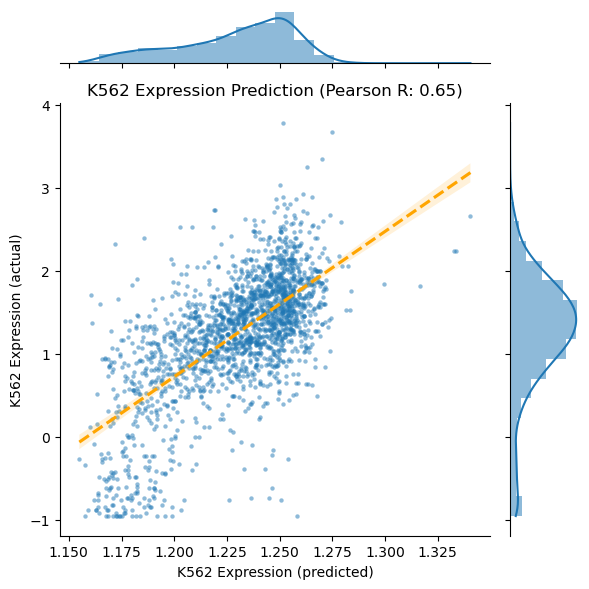

In [7]:
plot_predictions(predictions, cell_line='K562', pred_col='PredExpr', actual_col='ActualExpr')
plt.show()

<Figure size 600x600 with 0 Axes>

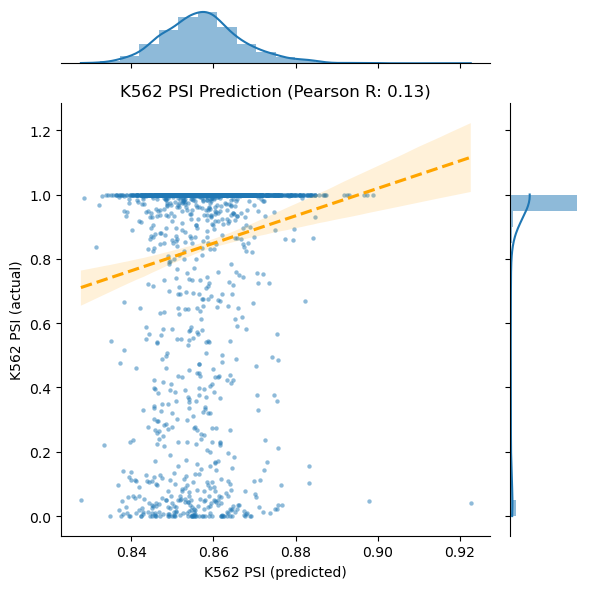

In [8]:
plot_predictions(predictions, cell_line='K562', pred_col='PredPsi', actual_col='ActualPsi')
plt.show()